In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import cv2
import sys
import os

plt.rcParams['figure.figsize'] = [10, 5]

In [ ]:
#data_path = r'D:\ProjectAeon\PatchTest\Collection2024_01_16_15_55_08'+'\\'
data_path = r'D:\ProjectAeon\PatchTestNewBlackMaterial\Collection2025_10_28_10_54_47'+'\\'

# Load relevant streams
# PelletMonitor csv values: False = Pellet delivery command, True = Pellet delivered (beam break)
pellet_monitor = pd.read_csv(data_path + 'PelletMonitor.csv')
pellet_monitor.columns = ['Seconds', 'Value']
pellet_monitor.set_index('Seconds', inplace=True)

pellets_detected = pd.read_csv(data_path + 'PelletsDetected.csv')
pellets_detected.columns = ['Seconds', 'Value']
pellets_detected.set_index('Seconds', inplace=True)

pixel_sum = pd.read_csv(data_path + 'PixelSum.csv')
pixel_sum.columns = ['Seconds', 'Value']
pixel_sum.set_index('Seconds', inplace=True)

cam_frames = pd.read_csv(data_path + 'CameraFrameIndex.csv')
cam_frames.columns = ['Seconds', 'Value']
cam_frames.set_index('Seconds', inplace=True)

In [23]:
# Setup functions defs
def get_frame_at_index(idx, vid):
    capture = cv2.VideoCapture(vid)
    capture.set(cv2.CAP_PROP_POS_FRAMES, idx)
    ret, frame = capture.read()

    return frame

FMP4


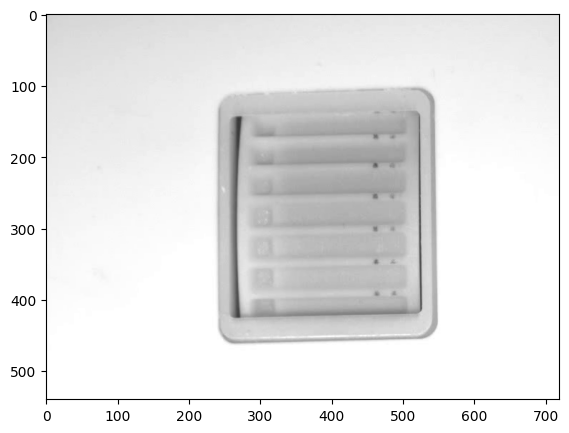

Frames in video = 4869.0, Frame indices recorded = 4869


In [24]:
# Video check
frame_to_check = 100


cap = cv2.VideoCapture(data_path + 'PatchVideo.avi')
print(int(cap.get(cv2.CAP_PROP_FOURCC)).to_bytes(4, byteorder=sys.byteorder).decode())
total_frames = cap.get(cv2.CAP_PROP_FRAME_COUNT)

cap.set(cv2.CAP_PROP_POS_FRAMES, frame_to_check)
ret, frame = cap.read()

plt.imshow(frame)
plt.show()

# Frame n check
print(f"Frames in video = {total_frames}, Frame indices recorded = {len(cam_frames)}")

Summary plots to look at pellet count for specified range of delivery commands


In [25]:
start_range = 0
end_range = 8

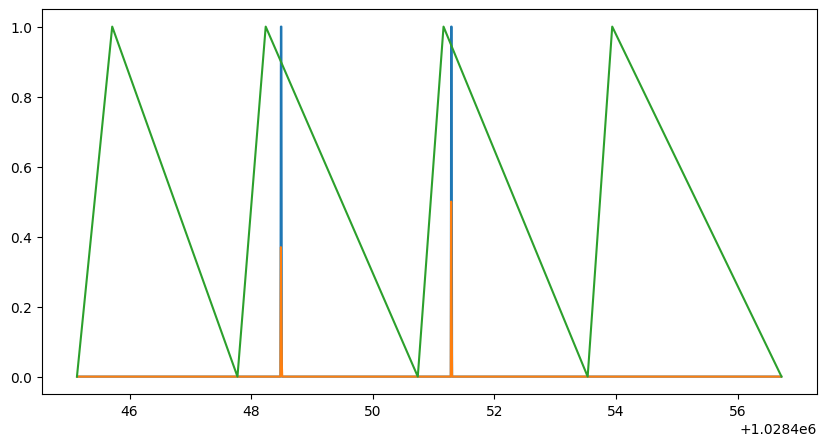

In [ ]:
# Summary plot
plot_range_start = pellet_monitor.index[start_range]
plot_range_end = pellet_monitor.index[end_range]

plt.figure()
plt.plot(pellets_detected["Value"][plot_range_start:plot_range_end])
plt.plot(pixel_sum["Value"][plot_range_start:plot_range_end] / np.max(pixel_sum["Value"][plot_range_start:plot_range_end])/2)
plt.plot(pellet_monitor["Value"][plot_range_start:plot_range_end])

In [ ]:
# Add some extra flags to the pellet monitor for non-standard delivery patterns

pellet_monitor['delivery_retry'] = pellet_monitor.Value.diff().eq(0) & pellet_monitor.Value.eq(0)
pellet_monitor['retry_count'] = pellet_monitor.groupby((pellet_monitor['delivery_retry'] == 0).cumsum())['delivery_retry'].cumsum()

pellet_monitor['beam_repeat'] = pellet_monitor.Value.diff().eq(0) & pellet_monitor.Value.eq(1)
pellet_monitor['beam_repeat_count'] = pellet_monitor.groupby((pellet_monitor['beam_repeat'] == 0).cumsum())['beam_repeat'].cumsum()

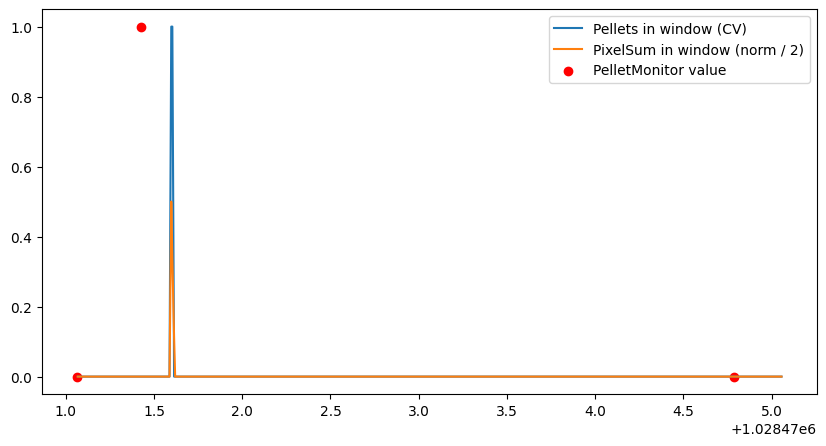

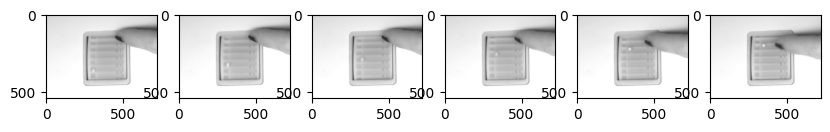

In [47]:
# Camera frames around pellet delivery times
delivery_index = 7

time_window_seconds = 4
delivery_datetime = pellet_monitor[pellet_monitor['Value'] == 0] # pellet_monitor['Value'] == 0 is when a delivery command arrives
datetime = delivery_datetime.index[delivery_index] 

# window for delivery
monitor_in_win = pellet_monitor['Value'][(pellet_monitor.index >= datetime) & (pellet_monitor.index <= datetime+time_window_seconds)]
pellets_in_win = pellets_detected['Value'][(pellets_detected.index >= datetime) & (pellets_detected.index <= datetime+time_window_seconds)]
pix_in_win = pixel_sum['Value'][(pixel_sum.index >= datetime) & (pixel_sum.index <= datetime+time_window_seconds)]

# plot time course
plt.figure()
plt.plot(pellets_in_win, label="Pellets in window (CV)")
plt.plot((pix_in_win / np.max(pix_in_win))/2, label="PixelSum in window (norm / 2)")
plt.scatter(monitor_in_win.index, monitor_in_win.values, c='r', label="PelletMonitor value")
plt.legend()

# Time when camera detected pellet
pellet_datetime = pellets_in_win[pellets_in_win.values > 0].index[0]
# Frame index for that time
frame_idx = cam_frames[cam_frames.index >= pellet_datetime].values[0][0]

fig, (ax1, ax2, ax3, ax4, ax5, ax6) = plt.subplots(1, 6)
ax1.imshow(get_frame_at_index(frame_idx - 2, data_path + 'PatchVideo.avi'))
ax2.imshow(get_frame_at_index(frame_idx, data_path + 'PatchVideo.avi'))
ax3.imshow(get_frame_at_index(frame_idx + 2, data_path + 'PatchVideo.avi'))
ax4.imshow(get_frame_at_index(frame_idx + 4, data_path + 'PatchVideo.avi'))
ax5.imshow(get_frame_at_index(frame_idx + 6, data_path + 'PatchVideo.avi'))
ax6.imshow(get_frame_at_index(frame_idx + 8, data_path + 'PatchVideo.avi'))
plt.show()

In [56]:
# Are there any multi deliveries present?
index_to_inspect = 0 # choose which of the multi pellet timestamps to center around


multi_pellet_dt = pellets_detected[pellets_detected['Value'].ge(2)]
multi_pellet_dt['group_diff'] = multi_pellet_dt.index
multi_pellet_dt['group_diff'] = multi_pellet_dt['group_diff'].diff().gt(2).cumsum()
if len(multi_pellet_dt['group_diff'])<=0:
    print("No MultiDeliveries in this dataset")
else:
    datetime = multi_pellet_dt.index[index_to_inspect] 

    # data window
    monitor_in_win = pellet_monitor['Value'][(pellet_monitor.index >= datetime-time_window_seconds) & (pellet_monitor.index <= datetime+time_window_seconds)]
    pellets_in_win = pellets_detected['Value'][(pellets_detected.index >= datetime-time_window_seconds) & (pellets_detected.index <= datetime+time_window_seconds)]
    pix_in_win = pixel_sum['Value'][(pixel_sum.index >= datetime-time_window_seconds) & (pixel_sum.index <= datetime+time_window_seconds)]

    # plot time course
    plt.figure()
    plt.plot(pellets_in_win)
    plt.plot((pix_in_win / np.max(pix_in_win))/2)
    plt.scatter(monitor_in_win.index, monitor_in_win.values, c='r')

    # Time when camera first detected pellet
    pellet_dt = pellets_in_win[pellets_in_win.values > 0].index[0]
    # Frame index for that time
    frame_idx = cam_frames[cam_frames.index >= pellet_dt].values[0][0]

    # DEBUG group by time
    fig, axs = plt.subplots(2, 6)
    axs[0,0].imshow(get_frame_at_index(frame_idx - 10, data_path + 'PatchVideo.avi'))
    axs[0,1].imshow(get_frame_at_index(frame_idx - 8, data_path + 'PatchVideo.avi'))
    axs[0,2].imshow(get_frame_at_index(frame_idx - 6, data_path + 'PatchVideo.avi'))
    axs[0,3].imshow(get_frame_at_index(frame_idx - 4, data_path + 'PatchVideo.avi'))
    axs[0,4].imshow(get_frame_at_index(frame_idx - 3, data_path + 'PatchVideo.avi'))
    axs[0,5].imshow(get_frame_at_index(frame_idx - 2, data_path + 'PatchVideo.avi'))
    axs[1,0].imshow(get_frame_at_index(frame_idx + 0, data_path + 'PatchVideo.avi'))
    axs[1,1].imshow(get_frame_at_index(frame_idx + 2, data_path + 'PatchVideo.avi'))
    axs[1,2].imshow(get_frame_at_index(frame_idx + 4, data_path + 'PatchVideo.avi'))
    axs[1,3].imshow(get_frame_at_index(frame_idx + 6, data_path + 'PatchVideo.avi'))
    axs[1,4].imshow(get_frame_at_index(frame_idx + 8, data_path + 'PatchVideo.avi'))
    axs[1,5].imshow(get_frame_at_index(frame_idx + 10, data_path + 'PatchVideo.avi'))
    plt.show()

    plt.figure()
    plt.imshow(get_frame_at_index(frame_idx + 10, data_path + 'PatchVideo.avi'))
    plt.show()
    pellets_detected['Value'].plot()

No MultiDeliveries in this dataset


In [58]:
total_deliveries = len(pellet_monitor[(pellet_monitor['Value'].eq(0)) & pellet_monitor['retry_count'].eq(0)])

# double pellet rate
double_pellet_rate = (multi_pellet_dt['group_diff'].max() + 1) / total_deliveries
double_pellet_rate = 0 if np.isnan(double_pellet_rate) else double_pellet_rate

# retry rate
retry_rate = pellet_monitor['delivery_retry'][pellet_monitor['delivery_retry'].eq(1)].cumsum().max() / total_deliveries
retry_rate = 0 if np.isnan(retry_rate) else retry_rate

# multiple beam breaks
multi_beam_break_rate = pellet_monitor['beam_repeat'][pellet_monitor['beam_repeat'].eq(1)].cumsum().max() / total_deliveries

results = pd.DataFrame({
    'total_deliveries': [total_deliveries],
    'double_pellet_rate': [double_pellet_rate],
    'retry_rate': [retry_rate],
    'multi_beam_break_rate': [multi_beam_break_rate]
})

print(results)

   total_deliveries  double_pellet_rate  retry_rate  multi_beam_break_rate
0                 9                   0           0               0.111111


In [59]:
data_path

'D:\\ProjectAeon\\PatchTestNewBlackMaterial\\Collection2025_10_28_10_54_47\\'

In [ ]:
save_path = data_path + "SummaryResults.csv"
results.to_csv(save_path)